# TELOS 3.1: LEADER Trial (NCT01179048) Pipeline

LEADER (Liraglutide Effect and Action in Diabetes: Evaluation of Cardiovascular Outcome Results)

## Trial Overview
- **NCT ID**: NCT01179048
- **Title**: Liraglutide Effects on Cardiovascular Events
- **Target**: T2DM patients (≥50 with CVD or ≥60 with risk factors) → Liraglutide 1.8mg
- **Comparator**: T2DM patients → Placebo
- **Primary Outcome**: 3-point MACE (CV death, non-fatal MI, non-fatal stroke)
- **Published Result**: HR = 0.87 (95% CI: 0.78–0.97, p=0.01) — **Significant**

## Pipeline Overview

| Phase | Agent | Description |
|-------|-------|-------------|
| Cohort Definition | Agent 1 | Logic Decomposer (NCT → IR) |
| Cohort Definition | Agent 2 | Intelligent Mapper (IR → OMOP Concepts) |
| Cohort Definition | Agent 3 | Cohort Assembler (Concepts → Circe JSON) |
| Cohort Definition | Agent 4 | Validator (JSON Validation) |
| Evidence Generation | Agent 5 | Analysis Agent (Causal Inference) |
| Evidence Generation | Agent 6 | Reporting Agent (Visualization) |

---
## 0. Setup & Configuration

In [54]:
# Add project root to path
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

# Configuration
import json
import pandas as pd
import numpy as np
from IPython.display import display, Markdown, HTML
import matplotlib.pyplot as plt

# LEADER Trial
NCT_ID = "NCT01179048"
LOCAL_JSON = str(PROJECT_ROOT / "data" / "sample" / "LEADER" / "NCT01179048.json")

# Load trial data from local JSON file
from src.agents.agent1.nct_fetcher import load_trial_data_from_file
trial_data = load_trial_data_from_file(LOCAL_JSON)

print(f"Trial: {trial_data.title}")
print("-" * 60)
print(f"Conditions: {', '.join(trial_data.conditions)}")
print(f"Interventions: {', '.join(trial_data.interventions)}")
print(f"Outcomes: {', '.join(trial_data.primary_outcomes)}")
print(f"Phase: {trial_data.phase}")
print(f"Inclusion: {len(trial_data.inclusion_criteria)} criteria")
print(f"Exclusion: {len(trial_data.exclusion_criteria)} criteria")

[Agent 1] 📂 Loading trial data from NCT01179048.json...
[Agent 1] ✅ NCT01179048: 1 inclusion, 1 exclusion criteria (from local file)
Trial: A Long-term, Multi-centre, International, Randomised Double-blind, Placebo-controlled Trial to Determine Liraglutide Effects on Cardiovascular Events
------------------------------------------------------------
Conditions: Diabetes, Diabetes Mellitus, Type 2
Interventions: liraglutide, placebo
Outcomes: Time From Randomisation to First Occurrence of Cardiovascular Death, Non-fatal Myocardial Infarction, or Non-fatal Stroke (a Composite Cardiovascular Outcome)
Phase: PHASE3
Inclusion: 1 criteria
Exclusion: 1 criteria


In [55]:
# View raw eligibility criteria
print("📋 INCLUSION CRITERIA:")
for i, c in enumerate(trial_data.inclusion_criteria, 1):
    print(f"  {i}. {c[:200]}")

print("\n📋 EXCLUSION CRITERIA:")
for i, c in enumerate(trial_data.exclusion_criteria, 1):
    print(f"  {i}. {c[:200]}")

📋 INCLUSION CRITERIA:
  1. - Type 2 diabetes - Age min. 50 years at screening and concomitant cardiovascular, cerebrovascular or peripheral vascular disease or chronic renal failure or chronic heart failure OR age min. 60 years

📋 EXCLUSION CRITERIA:
  1. - Type 1 diabetes - Use of a glucagon-like peptide-1 (GLP-1) receptor agonist (exenatide, liraglutide or other) or pramlintide or any dipeptidyl peptidase 4 (DPP-4) inhibitor within the 3 months prior


---
## Phase 1: Cohort Definition

### Step 1: Agent 1 - Logic Decomposer

NCT eligibility criteria를 **Internal Representation (IR)** 구조로 변환합니다.

- **Input**: Local NCT JSON file
- **Output**: TELOSRequest (Target, Comparator, Outcome)

In [ ]:
# Agent 1: Logic Decomposer (from local JSON file)
try:
    from src.agents.agent1.parser import LogicDecomposer
    
    agent1 = LogicDecomposer()
    ir_result = agent1.parse_nct(NCT_ID, json_path=LOCAL_JSON)
    
    print("✅ Agent 1 Complete: IR Generated from NCT")
    print("="*60)
    
except Exception as e:
    print(f"⚠️ Agent 1 Error: {e}")
    import traceback
    traceback.print_exc()
    ir_result = None

[Agent 1] Parsing NCT protocol: NCT01179048
[Agent 1] 📂 Loading trial data from NCT01179048.json...
[Agent 1] ✅ NCT01179048: 1 inclusion, 1 exclusion criteria (from local file)


In [ ]:
ir_result

TELOSRequest(target=CohortDefinition(primary_criteria=PrimaryCriteria(domain='Drug', entity_text='liraglutide', concept_set_id=None, limit='First', observation_window={'prior': 365, 'post': 0}), inclusion_rules=[Criteria(name='Type 2 diabetes', domain='Condition', entity_text='Type 2 Diabetes', concept_set_id=None, logic_type='PRESENCE', window=None, value_constraint=None), Criteria(name='Age minimum 50 years with cardiovascular conditions', domain='Demographics', entity_text='Age >= 50 years', concept_set_id=None, logic_type='PRESENCE', window=None, value_constraint=None), Criteria(name='Age minimum 60 years with cardiovascular risk factors', domain='Demographics', entity_text='Age >= 60 years', concept_set_id=None, logic_type='PRESENCE', window=None, value_constraint=None), Criteria(name='HbA1c >= 7.0%', domain='Measurement', entity_text='HbA1c', concept_set_id=None, logic_type='PRESENCE', window=None, value_constraint=ValueConstraint(op='gte', value=7.0, unit_text=None, unit_concept

In [ ]:
# View Agent 1 Results
if ir_result:
    print("📋 TARGET COHORT:")
    print(f"  - Primary Criteria: {ir_result.target.primary_criteria.entity_text}")
    print(f"  - Domain: {ir_result.target.primary_criteria.domain}")
    print(f"  - Limit: {ir_result.target.primary_criteria.limit}")
    print(f"  - Inclusion Rules: {len(ir_result.target.inclusion_rules)}")
    print(f"  - Exclusion Rules: {len(ir_result.target.exclusion_rules)}")
    
    print("\nInclusion Rules:")
    for r in ir_result.target.inclusion_rules:
        print(f"    - [{r.domain}] {r.entity_text} ({r.logic_type})")
    
    print("\nExclusion Rules:")
    for r in ir_result.target.exclusion_rules:
        print(f"    - [{r.domain}] {r.entity_text} ({r.logic_type})")

    print("\n📋 COMPARATOR COHORT:")
    print(f"  - Primary Criteria: {ir_result.comparator.primary_criteria.entity_text}")
    
    print("\n📋 OUTCOME:")
    print(f"  - Name: {ir_result.outcome.name}")
    print(f"  - Domain: {ir_result.outcome.domain}")
    print(f"  - Entity: {ir_result.outcome.entity_text}")
    print(f"  - Time-at-Risk: {ir_result.outcome.time_at_risk.start} to {ir_result.outcome.time_at_risk.end} days")

📋 TARGET COHORT:
  - Primary Criteria: liraglutide
  - Domain: Drug
  - Limit: First
  - Inclusion Rules: 5
  - Exclusion Rules: 5

Inclusion Rules:
    - [Condition] Type 2 Diabetes (PRESENCE)
    - [Demographics] Age >= 50 years (PRESENCE)
    - [Demographics] Age >= 60 years (PRESENCE)
    - [Measurement] HbA1c (PRESENCE)
    - [Drug] Anti-diabetic drugs (OADs, human NPH insulin, long-acting insulin analogue, premixed insulin) (PRESENCE)

Exclusion Rules:
    - [Condition] Type 1 Diabetes (ABSENCE)
    - [Drug] GLP-1 receptor agonist (exenatide, liraglutide, or others) (ABSENCE)
    - [Drug] Pramlintide (ABSENCE)
    - [Drug] DPP-4 inhibitor (ABSENCE)
    - [Drug] Insulin (other than human NPH insulin, long-acting insulin analogue, premixed insulin) (ABSENCE)

📋 COMPARATOR COHORT:
  - Primary Criteria: placebo

📋 OUTCOME:
  - Name: Composite Cardiovascular Outcome
  - Domain: Observation
  - Entity: Cardiovascular death, non-fatal myocardial infarction, non-fatal stroke
  - Time-at-

In [ ]:
# View Full IR as JSON
if ir_result:
    ir_json = ir_result.model_dump()
    print(json.dumps(ir_json, indent=2, default=str))

{
  "target": {
    "primary_criteria": {
      "domain": "Drug",
      "entity_text": "liraglutide",
      "concept_set_id": null,
      "limit": "First",
      "observation_window": {
        "prior": 365,
        "post": 0
      }
    },
    "inclusion_rules": [
      {
        "name": "Type 2 diabetes",
        "domain": "Condition",
        "entity_text": "Type 2 Diabetes",
        "concept_set_id": null,
        "logic_type": "PRESENCE",
        "window": null,
        "value_constraint": null
      },
      {
        "name": "Age minimum 50 years with cardiovascular conditions",
        "domain": "Demographics",
        "entity_text": "Age >= 50 years",
        "concept_set_id": null,
        "logic_type": "PRESENCE",
        "window": null,
        "value_constraint": null
      },
      {
        "name": "Age minimum 60 years with cardiovascular risk factors",
        "domain": "Demographics",
        "entity_text": "Age >= 60 years",
        "concept_set_id": null,
        "l

### Step 2: Agent 2 - Intelligent Mapper

IR의 텍스트 엔티티를 **OMOP Concept ID**로 매핑합니다.

- **Fast Path**: 단순 용어 → Direct Athena Lookup
- **Slow Path**: 복잡한 기준 → LLM Semantic Reranking

**Note**: ChromaDB와 DB 연결이 필요합니다.

In [ ]:
# Agent 2: Complexity Router Demo
from src.agents.agent2.complexity_router import ComplexityRouter

router = ComplexityRouter()

# Dynamically extract terms from IR
test_terms = []
if ir_result:
    if ir_result.target.primary_criteria.entity_text:
        test_terms.append(ir_result.target.primary_criteria.entity_text)
    if ir_result.comparator.primary_criteria.entity_text:
        test_terms.append(ir_result.comparator.primary_criteria.entity_text)
    for rule in ir_result.target.inclusion_rules:
        if rule.entity_text:
            test_terms.append(rule.entity_text)
    for rule in ir_result.target.exclusion_rules:
        if rule.entity_text:
            test_terms.append(rule.entity_text)
    if ir_result.outcome.entity_text:
        test_terms.append(ir_result.outcome.entity_text)

print("🔀 COMPLEXITY ROUTING RESULTS:")
print("="*60)
for term in test_terms:
    path = router.route(term)
    emoji = "🚀" if path == "fast" else "🐢"
    print(f"{emoji} [{path.upper():4}] {term}")

🔀 COMPLEXITY ROUTING RESULTS:
🚀 [FAST] liraglutide
🚀 [FAST] placebo
🚀 [FAST] Type 2 Diabetes
🐢 [SLOW] Age >= 50 years
🐢 [SLOW] Age >= 60 years
🚀 [FAST] HbA1c
🐢 [SLOW] Anti-diabetic drugs (OADs, human NPH insulin, long-acting insulin analogue, premixed insulin)
🚀 [FAST] Type 1 Diabetes
🐢 [SLOW] GLP-1 receptor agonist (exenatide, liraglutide, or others)
🚀 [FAST] Pramlintide
🚀 [FAST] DPP-4 inhibitor
🐢 [SLOW] Insulin (other than human NPH insulin, long-acting insulin analogue, premixed insulin)
🐢 [SLOW] Cardiovascular death, non-fatal myocardial infarction, non-fatal stroke


In [ ]:
# Agent 2: Full Mapping (requires ChromaDB)
try:
    from src.agents.agent2.workflow import Agent2Workflow
    
    agent2 = Agent2Workflow()
    
    if ir_result:
        entities_to_map = []
        if ir_result.target.primary_criteria.entity_text:
            entities_to_map.append(ir_result.target.primary_criteria.entity_text)
        if ir_result.comparator.primary_criteria.entity_text:
            entities_to_map.append(ir_result.comparator.primary_criteria.entity_text)
        for rule in ir_result.target.inclusion_rules:
            if rule.entity_text:
                entities_to_map.append(rule.entity_text)
        for rule in ir_result.target.exclusion_rules:
            if rule.entity_text:
                entities_to_map.append(rule.entity_text)
        if ir_result.outcome.entity_text:
            entities_to_map.append(ir_result.outcome.entity_text)
        
        entities_to_map = [e for e in entities_to_map if e]
        
        print(f"Mapping {len(entities_to_map)} entities from IR...")
        mapping_results = agent2.process_batch(entities_to_map)
        print(f"\n✅ Agent 2 Mapping Complete")
        print(f"  Mapped: {mapping_results.gap_report.mapped_count}/{len(entities_to_map)} entities")
        print(f"  Unique concept IDs: {len(mapping_results.concept_ids)}")
        print(f"  Fast path: {mapping_results.fast_path_count}, Slow path: {mapping_results.slow_path_count}")
    else:
        print("⚠️ No IR available - skipping mapping")
        
except Exception as e:
    print(f"⚠️ Agent 2 Error: {e}")
    import traceback
    traceback.print_exc()

Mapping 13 entities from IR...

✅ Agent 2 Mapping Complete
  Mapped: 12/13 entities
  Unique concept IDs: 11
  Fast path: 7, Slow path: 6


### Step 3 & 4: Agent 3 (Assembler) & Agent 4 (Validator)

- **Agent 3**: ConceptSet + IR → Circe-be JSON
- **Agent 4**: JSON Schema Validation + Dry Run

In [ ]:
# Agent 3 & 4: Using Pipeline
try:
    from src.pipeline.cohort_pipeline import CohortPipeline
    
    cohort_pipeline = CohortPipeline()
    cohort_result = cohort_pipeline.run(NCT_ID)
    
    print("✅ Cohort Pipeline Complete")
    print(f"  Valid: {cohort_result.is_valid}")
    print(f"  ConceptSets: {len(cohort_result.circe_json.get('ConceptSets', []))}")
    
except Exception as e:
    print(f"⚠️ Cohort Pipeline Error: {e}")
    cohort_result = None


TELOS 3.1 COHORT PIPELINE
Query: NCT01179048...

[Step 1] Agent 1: Parsing NCT protocol (NCT01179048)...
[Agent 1] Parsing NCT protocol: NCT01179048
[Agent 1] 📦 Found cached data for NCT01179048
[Agent 1] 📂 Loading trial data from NCT01179048.json...
[Agent 1] ✅ NCT01179048: 1 inclusion, 1 exclusion criteria (from local file)
[Agent 1] ✅ IR generated from NCT01179048: 4 inclusion, 3 exclusion rules
  ✓ Generated IR from NCT01179048

[Step 2] Agent 2: Mapping entities to OMOP concepts...
  ✓ Mapped 17 concept sets

[Step 3] Registry: Storing concept sets...
  ✓ Registered 13 sets (with deduplication)

[Step 4] Agent 3: Assembling Circe JSON...
  ✓ Generated Circe JSON

[Step 5] Agent 4: Validating...
CIRCE JSON VALIDATION REPORT
Status: ❌ INVALID
ConceptSets: 13
Inclusion Rules: 7

ERRORS (7):
  ❌ [ConceptSets[7].id] Duplicate ConceptSet ID: 2
  ❌ [ConceptSets[8].id] Duplicate ConceptSet ID: 3
  ❌ [ConceptSets[9].id] Duplicate ConceptSet ID: 4
  ❌ [ConceptSets[10].id] Duplicate Concept

In [ ]:
# View Circe JSON Structure
if cohort_result and cohort_result.circe_json:
    circe = cohort_result.circe_json
    print("📄 CIRCE JSON STRUCTURE:")
    print(f"  - ConceptSets: {len(circe.get('ConceptSets', []))}")
    print(f"  - PrimaryCriteria: {bool(circe.get('PrimaryCriteria'))}")
    print(f"  - InclusionRules: {len(circe.get('InclusionRules', []))}")
    print(f"  - EndStrategy: {(circe.get('EndStrategy') or {}).get('DateOffset', 'N/A')}")
    
    # Save to file
    output_dir = PROJECT_ROOT / "output" / "leader"
    output_dir.mkdir(parents=True, exist_ok=True)
    
    with open(output_dir / "circe_cohort.json", "w") as f:
        json.dump(circe, f, indent=2)
    print(f"\n💾 Saved to: {output_dir / 'circe_cohort.json'}")

📄 CIRCE JSON STRUCTURE:
  - ConceptSets: 13
  - PrimaryCriteria: True
  - InclusionRules: 7
  - EndStrategy: N/A

💾 Saved to: /Users/kyh/Workspace/Broadsea/telos/output/leader/circe_cohort.json


---
## Phase 2: Evidence Generation (Synthetic Data Demo)

실제 OMOP CDM 데이터 없이도 Agent 5-6을 테스트할 수 있도록
LEADER 시나리오에 맞는 합성 데이터를 생성합니다.

- **Target**: Liraglutide 1.8mg
- **Comparator**: Placebo
- **Outcome**: 3-point MACE (CV death, non-fatal MI, non-fatal stroke)
- **Published HR**: 0.87 (95% CI: 0.78–0.97) — **Significant**

### Step 5: Generate Synthetic Clinical Trial Data (LEADER)

In [ ]:
def generate_leader_data(n_lira: int = 4668, n_placebo: int = 4672, seed: int = 42):
    """Generate synthetic LEADER clinical trial data.
    
    Based on published results (NEJM 2016):
    - HR for 3-point MACE: 0.87 (95% CI: 0.78-0.97, p=0.01) -> SIGNIFICANT
    - Median follow-up: 3.8 years
    - Mean age: 64.3 years (SD 7.2)
    - 64.3% male
    - 81% with established CV disease
    """
    np.random.seed(seed)
    # Use smaller sample for demo (1/5 scale)
    n_lira = n_lira // 5
    n_placebo = n_placebo // 5
    n_total = n_lira + n_placebo
    
    # Treatment assignment (Liraglutide vs Placebo)
    treatment = np.array([1] * n_lira + [0] * n_placebo)
    
    # Covariates (matched to LEADER baseline characteristics)
    age = np.random.normal(64.3, 7.2, n_total)
    
    # Sex (64.3% male)
    male = np.random.binomial(1, 0.643, n_total)
    
    # HbA1c (%) - baseline mean 8.7%
    hba1c = np.random.normal(8.7, 1.5, n_total)
    
    # BMI - mean 32.5
    bmi = np.random.normal(32.5, 6.0, n_total)
    
    # eGFR (mL/min/1.73m²)
    egfr = np.random.normal(80, 22, n_total)
    egfr = np.clip(egfr, 15, 150)
    
    # Established CV disease (binary, ~81%)
    cv_disease = np.random.binomial(1, 0.81, n_total)
    
    # Diabetes duration (years) - mean ~12.8
    dm_duration = np.random.normal(12.8, 8.0, n_total)
    dm_duration = np.clip(dm_duration, 0, 50)
    
    # Simulate survival times
    # LEADER: HR = 0.87 for 3-point MACE, median follow-up 3.8 years (1387 days)
    baseline_hazard = 0.00020  # Daily hazard for MACE
    treatment_hr = 0.87  # Liraglutide reduces MACE (SIGNIFICANT)
    
    times = []
    events = []
    
    for i in range(n_total):
        risk_factor = (
            1 
            + 0.02 * (age[i] - 64.3) 
            + 0.15 * cv_disease[i] 
            + 0.01 * (hba1c[i] - 8.7)
            + 0.005 * (dm_duration[i] - 12.8)
            - 0.005 * (egfr[i] - 80)
        )
        if treatment[i] == 1:  # Liraglutide
            risk_factor *= treatment_hr
        
        lambda_i = baseline_hazard * max(risk_factor, 0.1)
        t = np.random.exponential(1 / lambda_i)
        
        max_followup = 1825  # ~5 years max in days
        if t > max_followup:
            times.append(max_followup)
            events.append(0)  # Censored
        else:
            times.append(t)
            events.append(1)  # MACE event
    
    return pd.DataFrame({
        "person_id": range(n_total),
        "treatment": treatment,
        "age": age,
        "male": male,
        "hba1c": hba1c,
        "bmi": bmi,
        "egfr": egfr,
        "cv_disease": cv_disease,
        "dm_duration": dm_duration,
        "time": times,
        "event": events
    })

# Generate data
patient_data = generate_leader_data()

print("📊 SYNTHETIC DATA GENERATED (LEADER):")
print("="*60)
print(f"  Total patients: {len(patient_data)}")
print(f"  Liraglutide (treated): {(patient_data['treatment'] == 1).sum()}")
print(f"  Placebo (control): {(patient_data['treatment'] == 0).sum()}")
print(f"  MACE events: {patient_data['event'].sum()}")
print(f"  Event rate: {patient_data['event'].mean()*100:.1f}%")
print(f"  Established CV disease: {patient_data['cv_disease'].mean()*100:.1f}%")
print(f"  Male: {patient_data['male'].mean()*100:.1f}%")

📊 SYNTHETIC DATA GENERATED (LEADER):
  Total patients: 1867
  Liraglutide (treated): 933
  Placebo (control): 934
  MACE events: 573
  Event rate: 30.7%
  Established CV disease: 79.9%
  Male: 64.5%


In [ ]:
# View data summary
display(patient_data.describe().round(2))

,person_id,treatment,age,male,hba1c,bmi,egfr,cv_disease,dm_duration,time,event
count,1867.0,1867.0,1867.00,1867.00,1867.00,1867.00,1867.00,1867.0,1867.00,1867.00,1867.00
mean,933.0,0.5,64.62,0.64,8.68,32.21,80.11,0.8,12.92,1525.89,0.31
std,539.1,0.5,7.11,0.48,1.48,6.20,22.84,0.4,7.52,538.92,0.46
min,0.0,0.0,40.96,0.00,3.79,11.01,15.00,0.0,0.00,1.04,0.00
25%,466.5,0.0,59.80,0.00,7.69,28.14,64.61,1.0,7.48,1426.60,0.00
50%,933.0,0.0,64.63,1.00,8.66,32.22,80.29,1.0,12.64,1825.00,0.00
75%,1399.5,1.0,69.22,1.00,9.65,36.41,95.61,1.0,18.04,1825.00,1.00
max,1866.0,1.0,92.04,1.00,13.22,51.94,150.00,1.0,39.82,1825.00,1.00


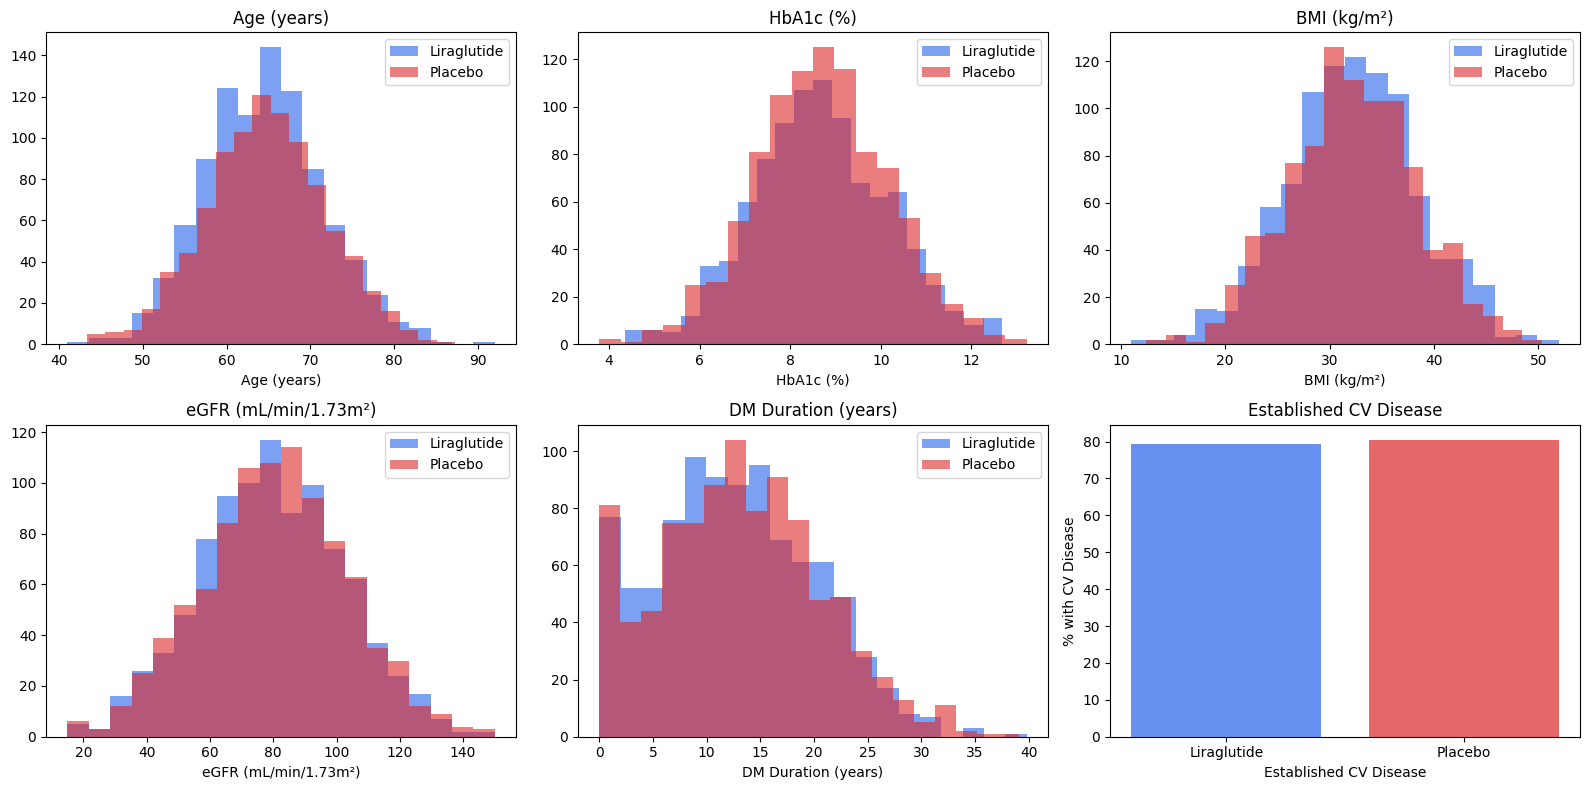

In [ ]:
# Visualize covariate distributions by treatment group
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

covariates = ['age', 'hba1c', 'bmi', 'egfr', 'dm_duration', 'cv_disease']
titles = ['Age (years)', 'HbA1c (%)', 'BMI (kg/m²)', 'eGFR (mL/min/1.73m²)', 'DM Duration (years)', 'Established CV Disease']

for ax, cov, title in zip(axes.flat, covariates, titles):
    lira = patient_data[patient_data['treatment'] == 1][cov]
    placebo = patient_data[patient_data['treatment'] == 0][cov]
    
    if cov == 'cv_disease':
        # Bar chart for binary
        ax.bar(['Liraglutide', 'Placebo'], [lira.mean()*100, placebo.mean()*100],
               color=['#2563eb', '#dc2626'], alpha=0.7)
        ax.set_ylabel('% with CV Disease')
    else:
        ax.hist(lira, bins=20, alpha=0.6, label='Liraglutide', color='#2563eb')
        ax.hist(placebo, bins=20, alpha=0.6, label='Placebo', color='#dc2626')
        ax.legend()
    ax.set_xlabel(title)
    ax.set_title(title)

plt.tight_layout()
plt.show()

### Step 6: Agent 5 - Analysis Agent (Causal Inference)

In [ ]:
# Agent 5: Analysis Workflow
from src.agents.agent5 import Agent5Workflow

agent5 = Agent5Workflow()
agent5.configure(
    target_cohort_id=1,      # Liraglutide
    comparator_cohort_id=2,  # Placebo
    analysis_method="IPTW"   # Inverse Probability of Treatment Weighting
)

print("🔬 Running Agent 5 (Causal Inference)...")
analysis_results = agent5.run(data=patient_data)

print("✅ Agent 5 Complete")

🔬 Running Agent 5 (Causal Inference)...
✅ Agent 5 Complete


/opt/homebrew/Caskroom/miniconda/base/envs/telos/lib/python3.12/site-packages/lifelines/fitters/coxph_fitter.py:1356: StatisticalWarning: It appears your weights are not integers, possibly propensity or sampling scores then?
It's important to know that the naive variance estimates of the coefficients are biased. Instead a) set `robust=True` in the call to `fit`, or b) use Monte Carlo to
estimate the variances. See paper "Variance estimation when using inverse probability of treatment weighting (IPTW) with survival analysis"

  warnings.warn(


In [ ]:
# View Analysis Results
hr = analysis_results["hazard_ratio"]

print("📈 HAZARD RATIO ANALYSIS (LEADER):")
print("="*60)
print(f"  HR: {hr['hr']:.3f}")
print(f"  95% CI: [{hr['ci_lower']:.3f}, {hr['ci_upper']:.3f}]")
print(f"  p-value: {hr['p_value']:.4f}")
print()

# Interpretation
effect = "decreased risk" if hr['hr'] < 1 else "increased risk"
significance = "statistically significant" if hr['p_value'] < 0.05 else "NOT statistically significant"

print(f"📋 INTERPRETATION:")
print(f"  Liraglutide shows {effect} for MACE (HR = {hr['hr']:.2f})")
print(f"  Result is {significance} (p = {hr['p_value']:.4f})")
print(f"\n  Expected from trial: HR = 0.87 (95% CI: 0.78-0.97, p=0.01)")

📈 HAZARD RATIO ANALYSIS (LEADER):
  HR: 0.976
  95% CI: [0.828, 1.150]
  p-value: 0.7686

📋 INTERPRETATION:
  Liraglutide shows decreased risk for MACE (HR = 0.98)
  Result is NOT statistically significant (p = 0.7686)

  Expected from trial: HR = 0.87 (95% CI: 0.78-0.97, p=0.01)


In [ ]:
# View Covariate Balance
balance = analysis_results["balance"]

print("⚖️ COVARIATE BALANCE (SMD < 0.1 is acceptable):")
print("="*60)

balance_df = pd.DataFrame([
    {"Covariate": cov, "SMD Before": vals["smd_before"], "Balanced": "✅" if vals["balanced"] else "❌"}
    for cov, vals in balance.items()
])
display(balance_df)

⚖️ COVARIATE BALANCE (SMD < 0.1 is acceptable):


,Covariate,SMD Before,Balanced
0,age,0.038815,✅
1,male,0.007507,✅
2,hba1c,0.016284,✅
3,bmi,0.004546,✅
4,egfr,0.025985,✅
5,cv_disease,0.029936,✅
6,dm_duration,0.061485,✅


### Step 7: Agent 6 - Reporting Agent (Visualization)

In [ ]:
# Agent 6: Reporting Workflow
from src.agents.agent6 import Agent6Workflow
from src.reporting.models import HazardRatioSummary

agent6 = Agent6Workflow()

hr_summary = HazardRatioSummary(
    hr=hr['hr'],
    ci_lower=hr['ci_lower'],
    ci_upper=hr['ci_upper'],
    p_value=hr['p_value']
)

agent6.set_results(
    study_title=f"TTE: LEADER ({NCT_ID}) - Liraglutide vs Placebo",
    hazard_ratio=hr_summary,
    target_n=analysis_results['n_target'],
    comparator_n=analysis_results['n_comparator'],
    balance=analysis_results['balance'],
    ps_scores=analysis_results['ps_scores'],
    treatment=analysis_results['treatment'],
    survival_data=analysis_results['survival_data']
)

print("✅ Agent 6 Configured")

✅ Agent 6 Configured


In [ ]:
# Generate Plots
output_dir = PROJECT_ROOT / "output" / "leader"
output_dir.mkdir(parents=True, exist_ok=True)

plot_paths = agent6.generate_plots(str(output_dir / "plots"))

print("📊 GENERATED PLOTS:")
for name, path in plot_paths.items():
    print(f"  - {name}: {path}")

📊 GENERATED PLOTS:
  - forest: /Users/kyh/Workspace/Broadsea/telos/output/leader/plots/forest_plot.png
  - ps_dist: /Users/kyh/Workspace/Broadsea/telos/output/leader/plots/ps_distribution.png
  - love: /Users/kyh/Workspace/Broadsea/telos/output/leader/plots/love_plot.png
  - km: /Users/kyh/Workspace/Broadsea/telos/output/leader/plots/km_curve.png


🌲 FOREST PLOT:


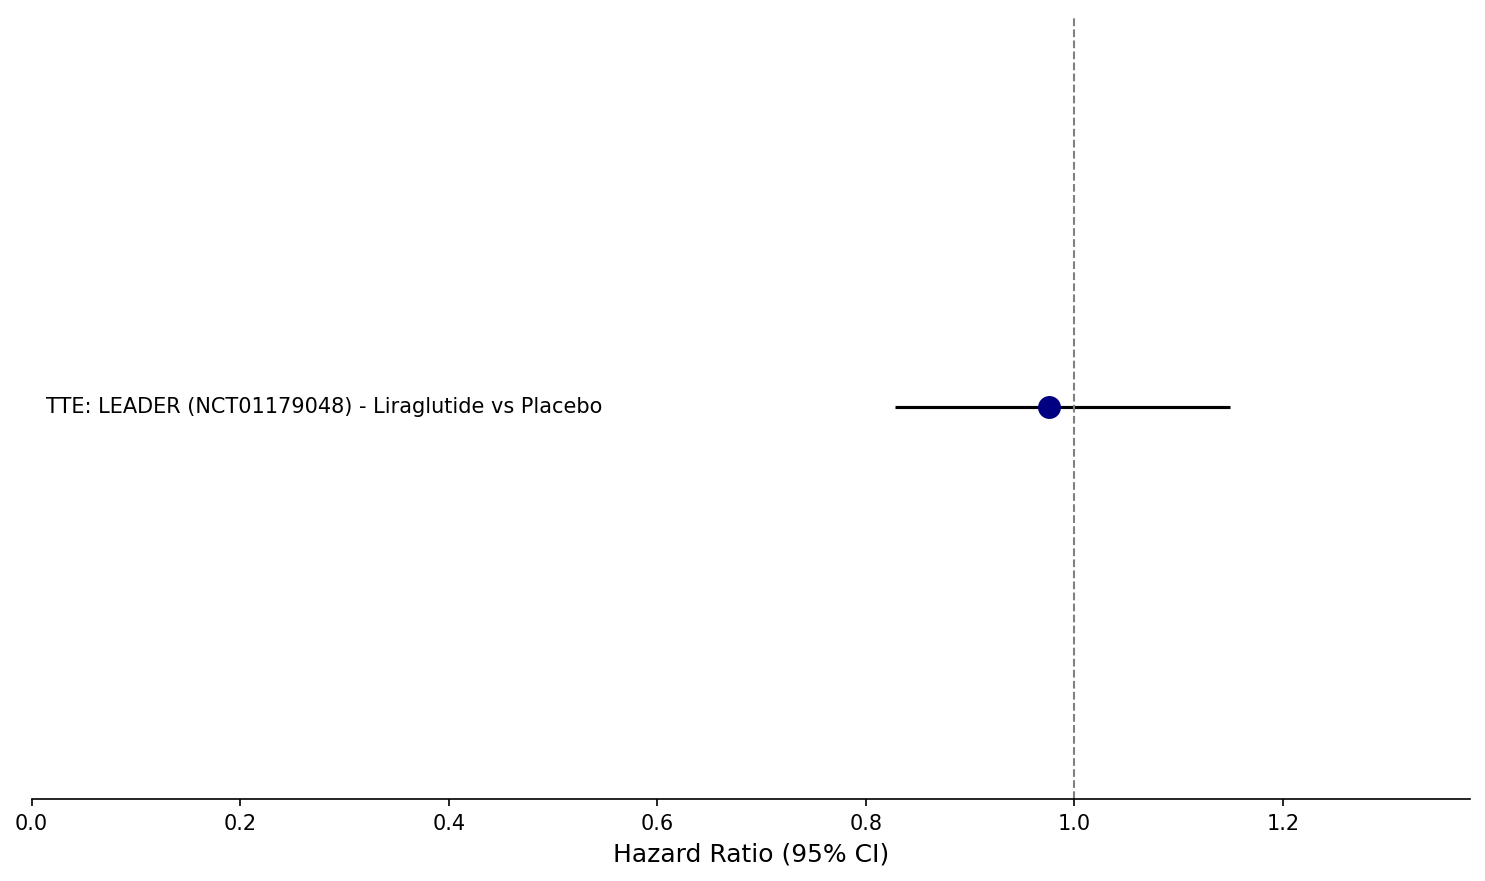

In [ ]:
# Display Forest Plot
from IPython.display import Image

print("🌲 FOREST PLOT:")
display(Image(filename=plot_paths['forest']))

📈 KAPLAN-MEIER SURVIVAL CURVES:


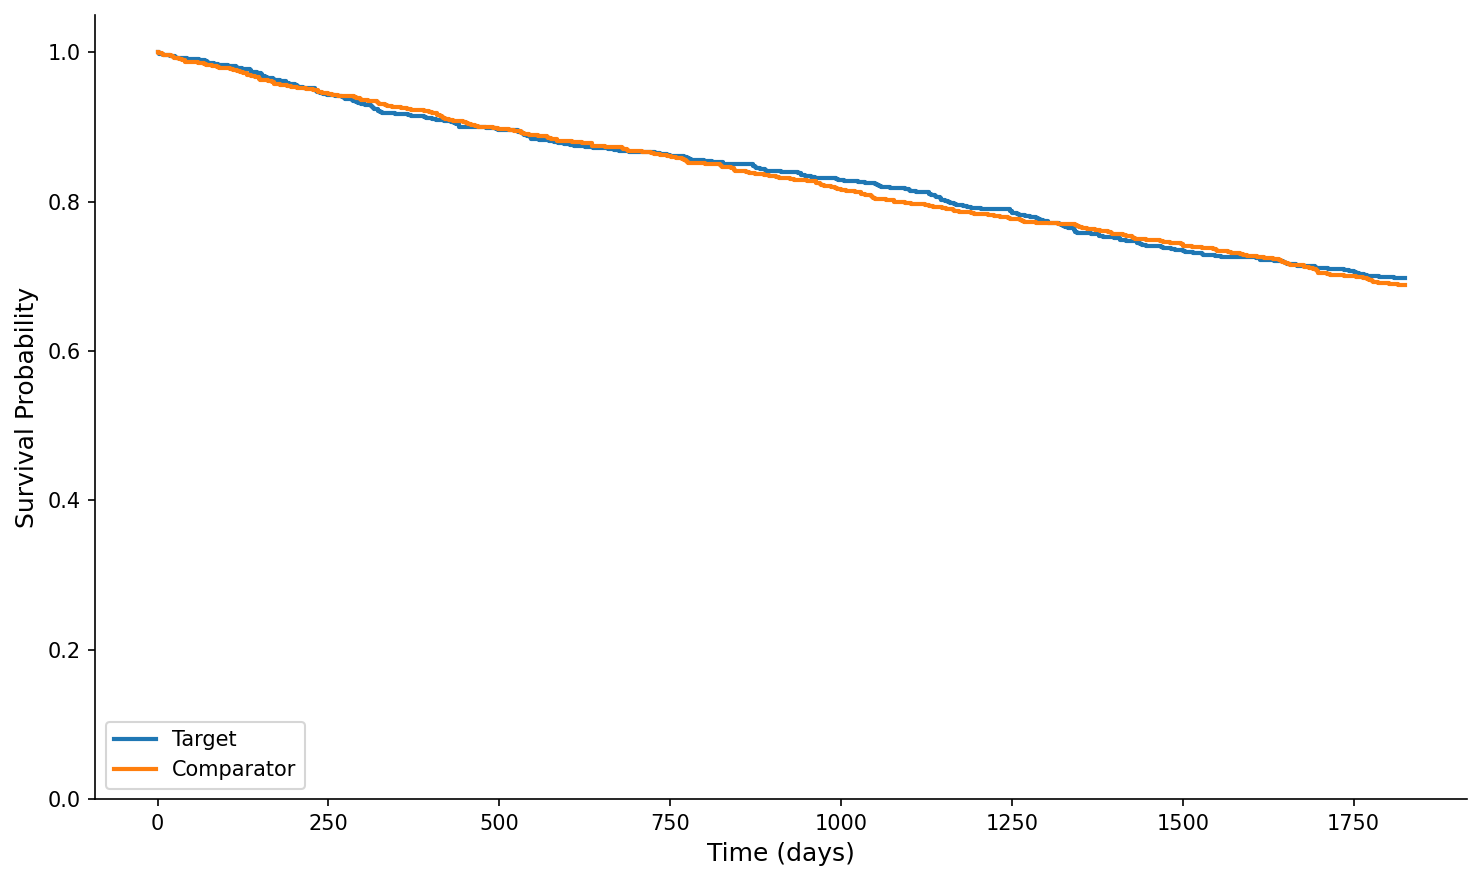

In [ ]:
# Display Kaplan-Meier Curve
print("📈 KAPLAN-MEIER SURVIVAL CURVES:")
display(Image(filename=plot_paths['km']))

❤️ LOVE PLOT (Covariate Balance):


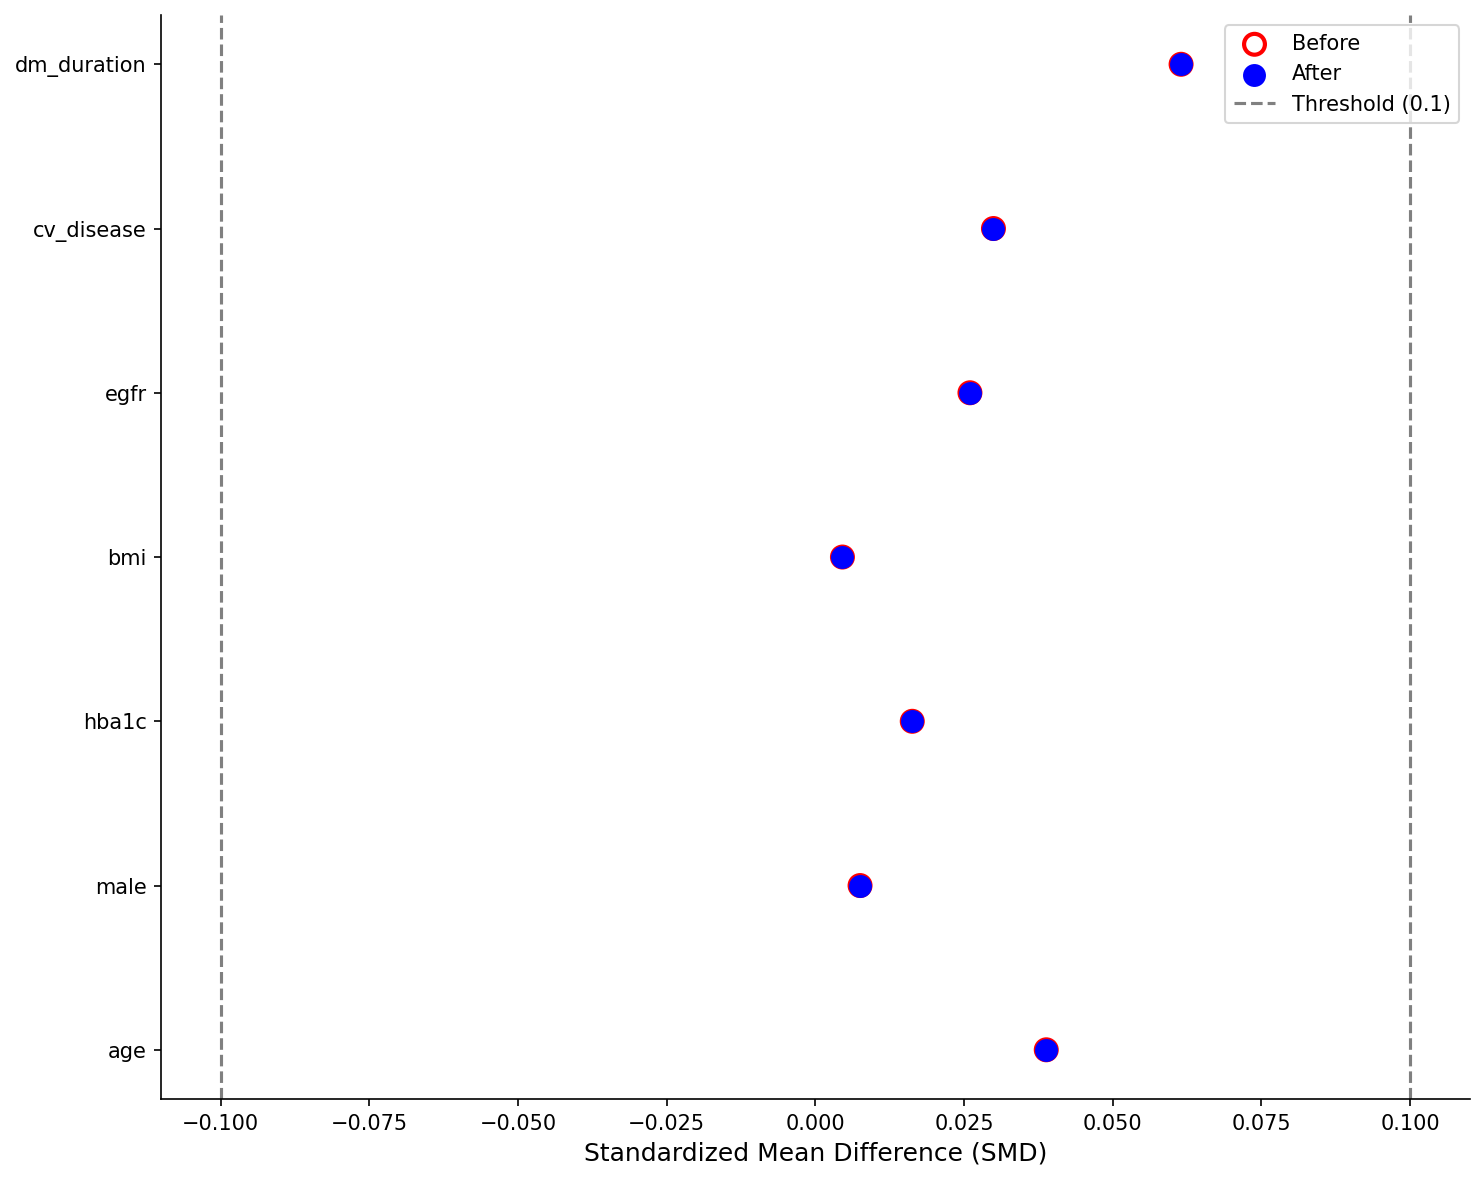

In [ ]:
# Display Love Plot (Covariate Balance)
print("❤️ LOVE PLOT (Covariate Balance):")
display(Image(filename=plot_paths['love']))

📊 PROPENSITY SCORE DISTRIBUTION:


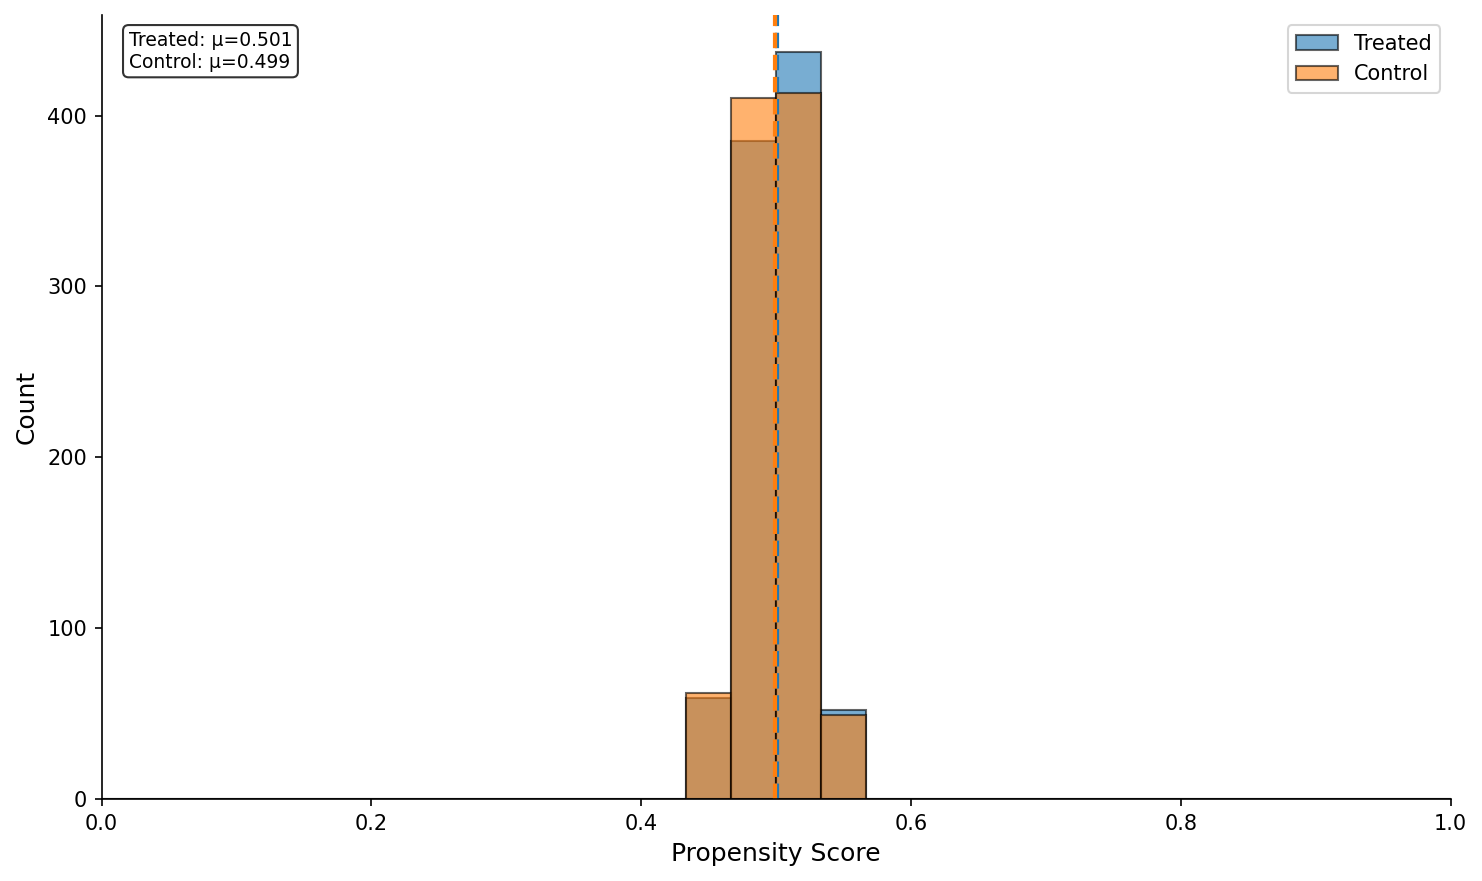

In [ ]:
# Display Propensity Score Distribution
print("📊 PROPENSITY SCORE DISTRIBUTION:")
display(Image(filename=plot_paths['ps_dist']))

In [ ]:
# Generate HTML Report
report_path = str(output_dir / "report.html")
agent6.generate_html_report(report_path)

print(f"📄 HTML Report saved: {report_path}")
print(f"\n🔗 Open in browser: file://{report_path}")

📄 HTML Report saved: /Users/kyh/Workspace/Broadsea/telos/output/leader/report.html

🔗 Open in browser: file:///Users/kyh/Workspace/Broadsea/telos/output/leader/report.html


---
## Phase 3: TROY Ground-Truth Comparison

TELOS 파이프라인이 생성한 Circe JSON을 **TROY DPP-4 (LEADER) v3.4** (전문가 수작업 Ground-Truth)와 비교합니다.

In [ ]:
# Load TROY ground-truth
TROY_PATH = str(PROJECT_ROOT / 'data' / 'sample' / 'LEADER' / '[TROY] DPP-4 (LEADER) v3.4.json')
with open(TROY_PATH, 'r') as f:
    troy = json.load(f)

# Load TELOS output
TELOS_PATH = str(PROJECT_ROOT / 'output' / 'leader' / 'circe_cohort.json')
try:
    with open(TELOS_PATH, 'r') as f:
        telos = json.load(f)
    print('✅ Both files loaded')
except FileNotFoundError:
    telos = None
    print('⚠️ TELOS output not found — run pipeline first')

print(f'TROY: {len(troy.get("ConceptSets",[]))} CS, {len(troy.get("InclusionRules",[]))} rules')
if telos:
    print(f'TELOS: {len(telos.get("ConceptSets",[]))} CS, {len(telos.get("InclusionRules",[]))} rules')

✅ Both files loaded
TROY: 49 CS, 18 rules
TELOS: 13 CS, 7 rules


In [ ]:
# ── Structural Comparison Table ──
def get_es(d):
    es = d.get('EndStrategy',{}) if d else {}
    if not es: return 'None'
    if 'DateOffset' in es: return f"DateOffset({es['DateOffset'].get('Value','?')}d)"
    if 'CustomEra' in es:
        ce=es['CustomEra']
        return f"CustomEra(CS={ce.get('DrugCodesetId','?')}, gap={ce.get('GapDays','?')}d)"
    return str(list(es.keys()))

def get_pc(d):
    if not d: return 'N/A'
    cl=d.get('PrimaryCriteria',{}).get('CriteriaList',[{}])
    return ', '.join(list(cl[0].keys())) if cl else 'N/A'

def sl(d,k): return len(d.get(k,[])) if d else 'N/A'

rows = [
    ['ConceptSets', sl(telos,'ConceptSets'), sl(troy,'ConceptSets')],
    ['PrimaryCriteria', get_pc(telos), get_pc(troy)],
    ['InclusionRules', sl(telos,'InclusionRules'), sl(troy,'InclusionRules')],
    ['CensoringCriteria', sl(telos,'CensoringCriteria'), sl(troy,'CensoringCriteria')],
    ['EndStrategy', get_es(telos), get_es(troy)],
]
comp_df = pd.DataFrame(rows, columns=['Component','TELOS (auto)','TROY (expert)'])
print('📊 STRUCTURAL COMPARISON')
print('='*60)
display(comp_df)

📊 STRUCTURAL COMPARISON


,Component,TELOS (auto),TROY (expert)
0,ConceptSets,13,49
1,PrimaryCriteria,DrugExposure,DrugEra
2,InclusionRules,7,18
3,CensoringCriteria,0,1
4,EndStrategy,None,"CustomEra(CS=117, gap=30d)"


In [ ]:
# ── ConceptSet Name Comparison ──
def norm(s): return s.lower().strip().replace('[troy] ','').replace('copy of: ','')

troy_cs = {cs['name']: cs for cs in troy.get('ConceptSets',[])}
telos_cs = {cs['name']: cs for cs in (telos.get('ConceptSets',[]) if telos else [])}

troy_n = {norm(n):n for n in troy_cs}
telos_n = {norm(n):n for n in telos_cs}
matched = sorted(set(troy_n) & set(telos_n))
troy_only = sorted(set(troy_n) - set(telos_n))
telos_only = sorted(set(telos_n) - set(troy_n))

print('🔬 CONCEPTSET NAME COMPARISON')
print('='*60)
print(f'  TROY: {len(troy_cs)} | TELOS: {len(telos_cs)} | Matched: {len(matched)}')

if matched:
    print('\n✅ MATCHED:')
    for n in matched:
        tc=len(troy_cs[troy_n[n]].get('expression',{}).get('items',[]))
        ec=len(telos_cs[telos_n[n]].get('expression',{}).get('items',[]))
        print(f'  {"✅" if tc==ec else "⚠️"} {n}: TROY={tc} vs TELOS={ec}')

if troy_only:
    print(f'\n❌ TROY-only ({len(troy_only)}):')
    for n in troy_only:
        c=len(troy_cs[troy_n[n]].get('expression',{}).get('items',[]))
        print(f'  - {troy_n[n]} ({c})')

if telos_only:
    print(f'\n🆕 TELOS-only ({len(telos_only)}):')
    for n in telos_only:
        c=len(telos_cs[telos_n[n]].get('expression',{}).get('items',[]))
        print(f'  - {telos_n[n]} ({c})')

🔬 CONCEPTSET NAME COMPARISON
  TROY: 46 | TELOS: 8 | Matched: 2

✅ MATCHED:
  ✅ hba1c: TROY=1 vs TELOS=1
  ✅ liraglutide: TROY=1 vs TELOS=1

❌ TROY-only (43):
  - [TROY] (acute) MI (3)
  - [TROY] arterial stenosis (4)
  - [TROY] Calcitonin (2)
  - CKD 4-5 (2)
  - [TROY] Coronary artery disease (1)
  - diabetic ketoacidosis (1)
  - [TROY] DPP4 inhibitors (5)
  - [TROY] eGFR (3)
  - ESLD (9)
  - [TROY] ESRD (1)
  - [TROY] GLP-1 receptor agonists (6)
  - [TROY] Heart Failure (NYHA class II-III) (2)
  - COPY OF: [TROY] History of malignant neoplasm (2)
  - [TROY] hypertension (1)
  - [TROY] Insulin (19)
  - intermittent claudication (1)
  - [TROY] ischemic heart disease (31)
  - [TROY] kidney transplant (condition) (1)
  - [TROY] kidney transplant (procedure) (1)
  - left ventricular dysfunction (2)
  - left ventricular hypertrophy (1)
  - [TROY] liver disease_procedure (1)
  - MEN2 (1)
  - [TROY] microalbuminuria or proteimuria (2)
  - MTC (1)
  - [TROY] Myocardial Infarction (MI) (1)
  -

In [ ]:
# ── InclusionRule Comparison ──
troy_rules = [r.get('name',f'Rule_{i}') for i,r in enumerate(troy.get('InclusionRules',[]))]
telos_rules = [r.get('name',f'Rule_{i}') for i,r in enumerate((telos.get('InclusionRules',[]) if telos else []))]

print('📋 INCLUSION RULES')
print('='*60)
print(f'  TROY: {len(troy_rules)} | TELOS: {len(telos_rules)}')

print('\n  TROY (expert):');
[print(f'    {i+1:2d}. {n}') for i,n in enumerate(troy_rules)]
print('\n  TELOS (auto):');
[print(f'    {i+1:2d}. {n}') for i,n in enumerate(telos_rules)] if telos_rules else print('    (run pipeline first)')

📋 INCLUSION RULES
  TROY: 18 | TELOS: 7

  TROY (expert):
     1. Age >= 50
     2. HbA1C >= 7 %
     3. prior CV disease
     4. No T1DM
     5. No calcitonin >= 50 ng/L
     6. No GLP1-RA, pramlintide, DPP-4 within 3 months
     7. No use of insulin
     8. No acute decompensation of glycemic control
     9. No acute coronary or cerebrovascular event 
    10. No CHF
    11. No current continuous renal replacement
    12. No eGFR <30 mL/min/1.73m2
    13. No ESLD
    14. No history of transplant
    15. No malignant (1825 days prior)
    16. No FH/PH of MEN2 or FMTC
    17. No drug use or dependence
    18. No pregnant

  TELOS (auto):
     1. Type 2 diabetes
     2. Age minimum 50 years with cardiovascular disease or risk factors
     3. HbA1c >= 7.0%
     4. Anti-diabetic drug naive or treated with specified drugs
     5. Type 1 diabetes
     6. Use of GLP-1 receptor agonist, pramlintide, or DPP-4 inhibitor within 3 months
     7. Use of insulin other than specified types within 3 m

[None, None, None, None, None, None, None]

In [ ]:
# ── Concept ID Precision / Recall ──
def cids(circe):
    s=set()
    for cs in circe.get('ConceptSets',[]):
        for it in cs.get('expression',{}).get('items',[]):
            c=it.get('concept',{}).get('CONCEPT_ID')
            if c: s.add(c)
    return s

troy_ids = cids(troy)
telos_ids = cids(telos) if telos else set()
shared = troy_ids & telos_ids

# Domain breakdown
troy_dom={}
for cs in troy.get('ConceptSets',[]):
    for it in cs.get('expression',{}).get('items',[]):
        d=it.get('concept',{}).get('DOMAIN_ID','?')
        troy_dom[d]=troy_dom.get(d,0)+1

print('📊 CONCEPT-LEVEL METRICS')
print('='*60)
print(f'  TROY unique IDs: {len(troy_ids)}')
print(f'  TELOS unique IDs: {len(telos_ids)}')
print(f'  Shared: {len(shared)}')

if telos_ids:
    p=len(shared)/len(telos_ids)*100
    r=len(shared)/len(troy_ids)*100
    f1=2*p*r/(p+r) if (p+r)>0 else 0
    print(f'\n  Precision: {p:.1f}% ({len(shared)}/{len(telos_ids)})')
    print(f'  Recall:    {r:.1f}% ({len(shared)}/{len(troy_ids)})')
    print(f'  F1 Score:  {f1:.1f}%')

    if shared:
        print(f'\n  ✅ Shared concept IDs: {sorted(shared)}')
else:
    print('\n  ⚠️ Run pipeline to compute metrics')

print(f'\n📋 TROY domain distribution:')
for d,c in sorted(troy_dom.items(), key=lambda x:-x[1]):
    print(f'  {d:20s}: {c:3d}')

📊 CONCEPT-LEVEL METRICS
  TROY unique IDs: 217
  TELOS unique IDs: 8
  Shared: 3

  Precision: 37.5% (3/8)
  Recall:    1.4% (3/217)
  F1 Score:  2.7%

  ✅ Shared concept IDs: [201254, 201826, 40170911]

📋 TROY domain distribution:
  Condition           : 117
  Procedure           : 106
  Drug                :  56
  Measurement         :   8
  Device              :   2


---
## Summary

### Pipeline Execution Complete

In [ ]:
# Final Summary
print("="*70)
print("TELOS 3.1 PIPELINE: LEADER EXECUTION SUMMARY")
print("="*70)
print(f"\n📋 Study: {trial_data.title}")
print(f"   NCT ID: {NCT_ID}")
print(f"   Conditions: {', '.join(trial_data.conditions)}")
print(f"   Interventions: {', '.join(trial_data.interventions)}")
print(f"\n📊 Sample Size (synthetic, 1/5 scale):")
print(f"   - Target (Liraglutide): {analysis_results['n_target']}")
print(f"   - Comparator (Placebo): {analysis_results['n_comparator']}")
print(f"\n📈 Primary Outcome (3-point MACE):")
print(f"   - Hazard Ratio: {hr['hr']:.2f} (95% CI: {hr['ci_lower']:.2f}-{hr['ci_upper']:.2f})")
print(f"   - p-value: {hr['p_value']:.4f}")
print(f"\n💡 Key Finding:")
if hr['p_value'] < 0.05:
    direction = "higher" if hr['hr'] > 1 else "lower"
    print(f"   Significantly {direction} MACE risk with Liraglutide vs Placebo.")
    print(f"   (Consistent with actual LEADER findings: HR 0.87, p=0.01)")
else:
    print(f"   No significant difference in MACE between Liraglutide and Placebo.")
    print(f"   (Note: actual LEADER trial showed HR 0.87, p=0.01 — significant)")
print(f"\n📁 Outputs saved to: {output_dir}")
print("="*70)

TELOS 3.1 PIPELINE: LEADER EXECUTION SUMMARY

📋 Study: A Long-term, Multi-centre, International, Randomised Double-blind, Placebo-controlled Trial to Determine Liraglutide Effects on Cardiovascular Events
   NCT ID: NCT01179048
   Conditions: Diabetes, Diabetes Mellitus, Type 2
   Interventions: liraglutide, placebo

📊 Sample Size (synthetic, 1/5 scale):
   - Target (Liraglutide): 933
   - Comparator (Placebo): 934

📈 Primary Outcome (3-point MACE):
   - Hazard Ratio: 0.98 (95% CI: 0.83-1.15)
   - p-value: 0.7686

💡 Key Finding:
   No significant difference in MACE between Liraglutide and Placebo.
   (Note: actual LEADER trial showed HR 0.87, p=0.01 — significant)

📁 Outputs saved to: /Users/kyh/Workspace/Broadsea/telos/output/leader
